### This is the notebook for analyzing UCEC data

In [2]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
from scipy.sparse import csr_matrix

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

import gseapy as gp
from gseapy import barplot, dotplot
from gseapy import Msigdb

import mygene
mg = mygene.MyGeneInfo()

import sys
sys.path.append("..")

from scripts.utility_functions import t_test, clean_data, read_data

cancer_type = "UCEC"
omic_type = "proteomics"

##### Step 1: organize the data into anndata object

In [3]:

df_transposed = read_data(cancer_type, omic_type)


In [4]:
### Make the anndata object
obs=pd.DataFrame(
    index=df_transposed.index, 
    data={
        'SampleType': df_transposed.index.str[-1],  # Last character
        'Sample': df_transposed.index.str[:-2]      # All but last two characters
    }
)

var=pd.DataFrame(
    index=df_transposed.columns, 
    data={
        "ensembl_ids_clean" : [x.split(".")[0] for x in df_transposed.columns]
    }
)

adata = ad.AnnData(
    X=df_transposed,
    obs=obs,
    var=var
)

print(adata)

AnnData object with n_obs × n_vars = 113 × 8813
    obs: 'SampleType', 'Sample'
    var: 'ensembl_ids_clean'


In [5]:
### Get gene symbol for ensembl ids (cleaned)
gene_info = mg.querymany(adata.var['ensembl_ids_clean'], scopes="ensembl.gene", fields = "symbol", species="human")
gene_symbols = {item['query']: item.get('symbol', None) for item in gene_info}

# Create a DataFrame to map Ensembl IDs to Gene Symbols
gene_mapping = pd.DataFrame(list(gene_symbols.items()), columns=['ensembl_ids_clean', 'Gene'])

# Merge with adata.var to add Gene_Symbol
adata.var = adata.var.join(gene_mapping.set_index("ensembl_ids_clean"), on='ensembl_ids_clean', how='left')

assert (adata.var.index == df_transposed.columns).all()
assert (adata.obs.index == df_transposed.index).all()

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
5 input query terms found no hit:	['ENSG00000112096', 'ENSG00000130723', 'ENSG00000148362', 'ENSG00000168078', 'ENSG00000215271']


In [6]:
adata.var_names
adata.var
#adata.obs


,ensembl_ids_clean,Gene
idx,,
ENSG00000000003.15,ENSG00000000003,TSPAN6
ENSG00000000419.12,ENSG00000000419,DPM1
ENSG00000000457.14,ENSG00000000457,SCYL3
ENSG00000000971.16,ENSG00000000971,CFH
ENSG00000001036.14,ENSG00000001036,FUCA2
...,...,...
ENSG00000284194.3,ENSG00000284194,SCO2
ENSG00000284691.1,ENSG00000284691,LOC728743
ENSG00000285025.1,ENSG00000285025,MIURF


In [7]:
object_file = f"../../MultiOmics_cancer_landscape_data/{cancer_type}/Object/{cancer_type}_{omic_type}.h5ad"

adata.write(object_file, compression="gzip")

##### Step 2: ML

In [8]:
### Main ML workflow 

# Load data
object_file = f"../../MultiOmics_cancer_landscape_data/{cancer_type}/Object/{cancer_type}_{omic_type}.h5ad"
adata = ad.read_h5ad(object_file)

X = adata.X
y_ori = adata.obs["SampleType"].values
#samples = adata.obs["Sample"].values  # sample names or IDs
samples_type = adata.obs["SampleType"].values
samples = adata.obs.index

# Encode labels
# LabelEncoder assigns integers alphabetically by default, so if your labels are "N" and "T" you’ll usually get "Normal" = 0, "Tumor" = 1
encoder = LabelEncoder()
y = encoder.fit_transform(y_ori)

# Ensure "Normal" = 0, "Tumor" = 1
if encoder.transform(["T"])[0] == 0:
    y = 1 - y  # flip labels

# Split train/test and also get the indices of the test set
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, range(len(y)), test_size=0.3, random_state=42, stratify=y, shuffle=True
)

adata_train = adata[samples[idx_train], ]
adata_test = adata[samples[idx_test], ]

# Train Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

adata_train = t_test(adata_obj = adata_train, sample_type_col= "SampleType", left_type = "T", right_type="N")

adata_train.var["feature_importance"] = rf.feature_importances_


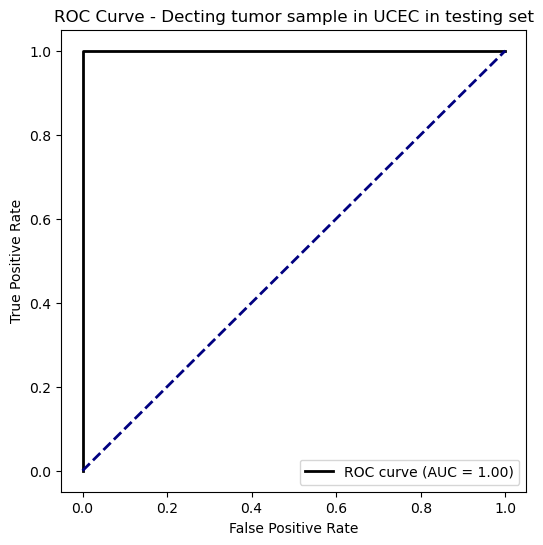

In [9]:

### Prediction
y_proba = rf.predict_proba(X_test)[:, 1]  # Probability of class 1 (Tumor)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute AUC
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color = "black", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color = "navy", lw=2, linestyle= "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - Decting tumor sample in {cancer_type} in testing set")
plt.legend(loc="lower right")

# Save to PDF
pdf_file = f"../results/figures/{cancer_type}_{omic_type}_ROC_in_testing_set.pdf"
plt.savefig(pdf_file, format="pdf", bbox_inches="tight")

plt.show()


    idx_test       Sample Sample_Type  y_test  y_pred
0        111  C3L-00008_T           T       1   0.978
1         79  C3L-00563_T           T       1   0.950
2         14       NX16_N           N       0   0.288
3        102  C3L-01925_T           T       1   0.824
4         66  C3N-00200_T           T       1   0.776
5        106  C3N-00848_T           T       1   0.972
6         19  C3L-01252_T           T       1   0.824
7         90  C3N-01346_T           T       1   0.900
8         59  C3N-00866_T           T       1   0.992
9         75  C3N-01267_T           T       1   0.938
10       104  C3L-00156_T           T       1   0.982
11        55  C3L-00780_T           T       1   0.958
12        64  C3L-00961_T           T       1   0.954
13        47  C3L-00601_T           T       1   0.964
14        12       NX14_N           N       0   0.422
15        72  C3N-01211_T           T       1   0.930
16       110  C3L-00136_T           T       1   0.904
17        50  C3N-01212_T   

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_29597/88673498.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=performance, x="Sample_Type", y="y_pred", palette=custom_palette)


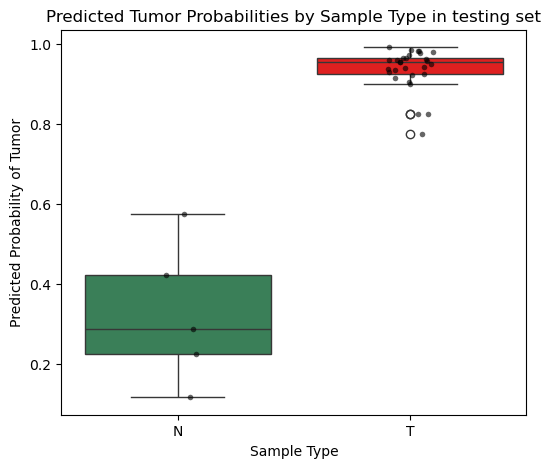

In [10]:

### Create performance DataFrame with Sample info and visualize the proba in testing set
performance = pd.DataFrame({
    "idx_test": idx_test,
    "Sample": samples[idx_test],   # sample names
    "Sample_Type": samples_type[idx_test],
    "y_test": y_test,
    "y_pred": y_proba
})

print(performance)

performance_sort = performance.sort_values("y_pred").reset_index(drop=True)

#pd.set_option("display.max_rows", None)
#print(performance_sort)

### Boxplot on the prediction score in testing set
custom_palette = {"N": "seagreen", "T": "red"}

plt.figure(figsize=(6,5))
sns.boxplot(data=performance, x="Sample_Type", y="y_pred", palette=custom_palette)
sns.stripplot(data=performance, x="Sample_Type", y="y_pred", color="black", size=4, jitter=True, alpha=0.6)
plt.ylabel("Predicted Probability of Tumor")
plt.xlabel("Sample Type")
plt.title("Predicted Tumor Probabilities by Sample Type in testing set")

# Save to PDF
pdf_file = f"../results/figures/{cancer_type}_{omic_type}_Proba_in_testing_set.pdf"
plt.savefig(pdf_file, format="pdf", bbox_inches="tight")

plt.show()

In [11]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
feature_importance_sort.head(5)

,ensembl_ids_clean,Gene,left_mean,right_mean,diff_mean,t_vals,p_vals,feature_importance
idx,,,,,,,,
ENSG00000122707.12,ENSG00000122707,RECK,21.503691280470512,23.119721289257146,-1.616030,-11.707667,1.213121e-10,0.017537
ENSG00000099250.18,ENSG00000099250,NRP1,24.064953369203128,25.344291653499354,-1.279338,-12.601079,2.683686e-11,0.014602
ENSG00000131378.14,ENSG00000131378,RFTN1,24.099278628022738,25.751162432042864,-1.651884,-10.828733,5.427489e-09,0.013740
ENSG00000121297.8,ENSG00000121297,TSHZ3,21.252356574290886,22.73850850955155,-1.486152,-16.711486,4.833976e-22,0.011150
ENSG00000128918.15,ENSG00000128918,ALDH1A2,25.912430078169976,27.91966954310254,-2.007239,-17.322237,2.355453e-25,0.011011


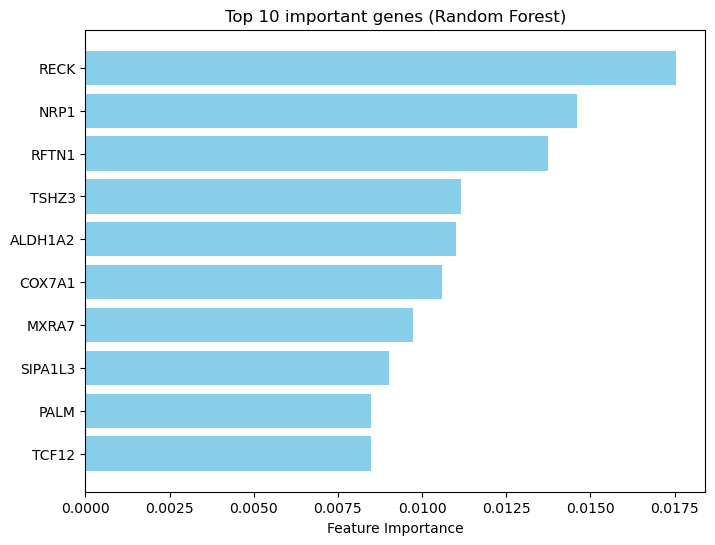

In [12]:
top_n = 10
plt.figure(figsize=(8,6))
plt.barh(
    feature_importance_sort['Gene'][:top_n][::-1],
    feature_importance_sort['feature_importance'][:top_n][::-1],
    color='skyblue'
)
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} important genes (Random Forest)")
plt.show()


#### Step 3: Explore the features with biological input

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_29597/1767341051.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


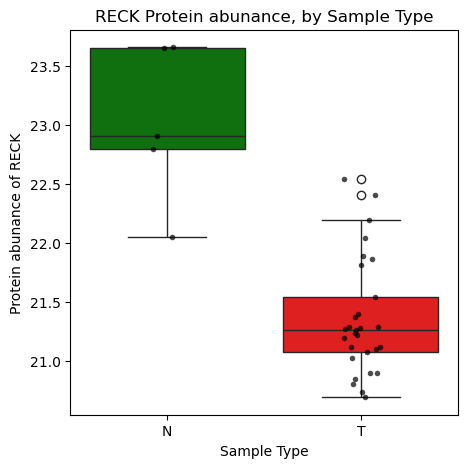

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_29597/1767341051.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


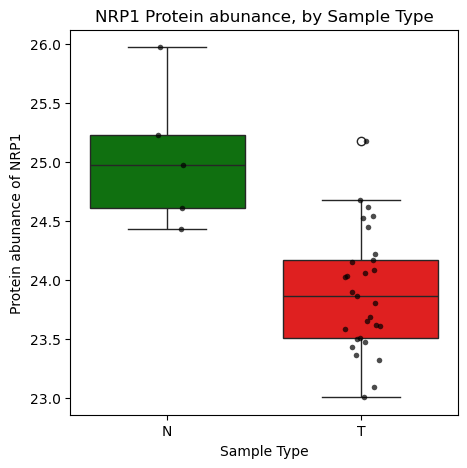

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_29597/1767341051.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


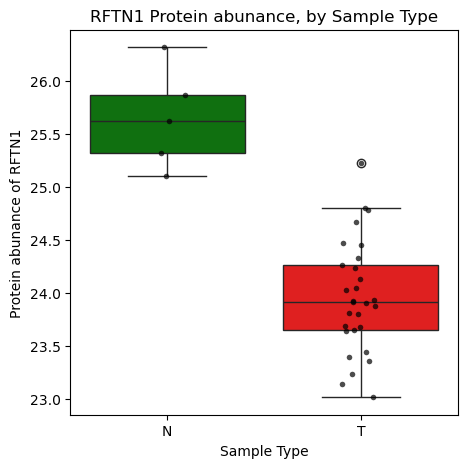

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_29597/1767341051.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


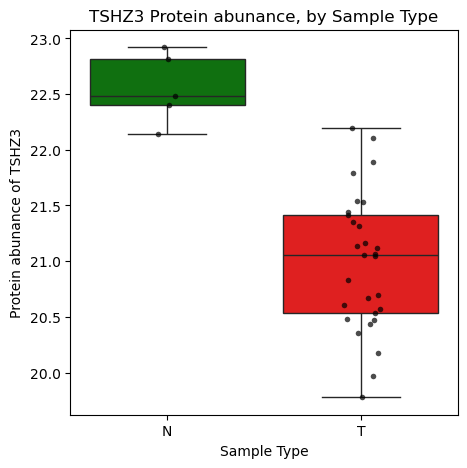

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_29597/1767341051.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


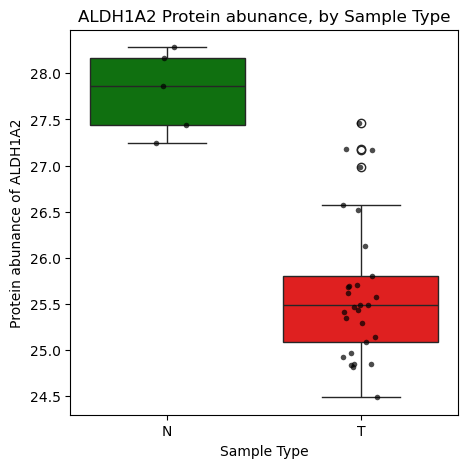

In [13]:
### Boxplot on important genes in testing set
selected_genes = feature_importance_sort.iloc[0:5, ].index.to_list()

df = pd.DataFrame(
    adata_test.X, 
    index=adata_test.obs.index,
    columns=adata_test.var.index  # or adata.var['Gene'] if you prefer gene symbols
).join(adata_test.obs)


for gene in selected_genes:
    
    plt.figure(figsize=(5,5))
    sns.boxplot(
        data=df, 
        x="SampleType", 
        y=gene, 
        palette={"N": "green", "T": "red"}
    )
    sns.stripplot(
        data=df, 
        x="SampleType", 
        y=gene, 
        color="black", 
        size=4, 
        jitter=True, 
        alpha=0.7
    )
    plt.ylabel(f"Protein abunance of {adata.var.loc[gene, 'Gene']}")
    plt.xlabel("Sample Type")
    plt.title(f"{adata.var.loc[gene, 'Gene']} Protein abunance, by Sample Type")
    plt.show()



In [15]:
# check if the NA is imputed
#adata[:, adata.var["Gene"] == "SCN7A" ].X

Total number of samples: 34


<Figure size 900x900 with 0 Axes>

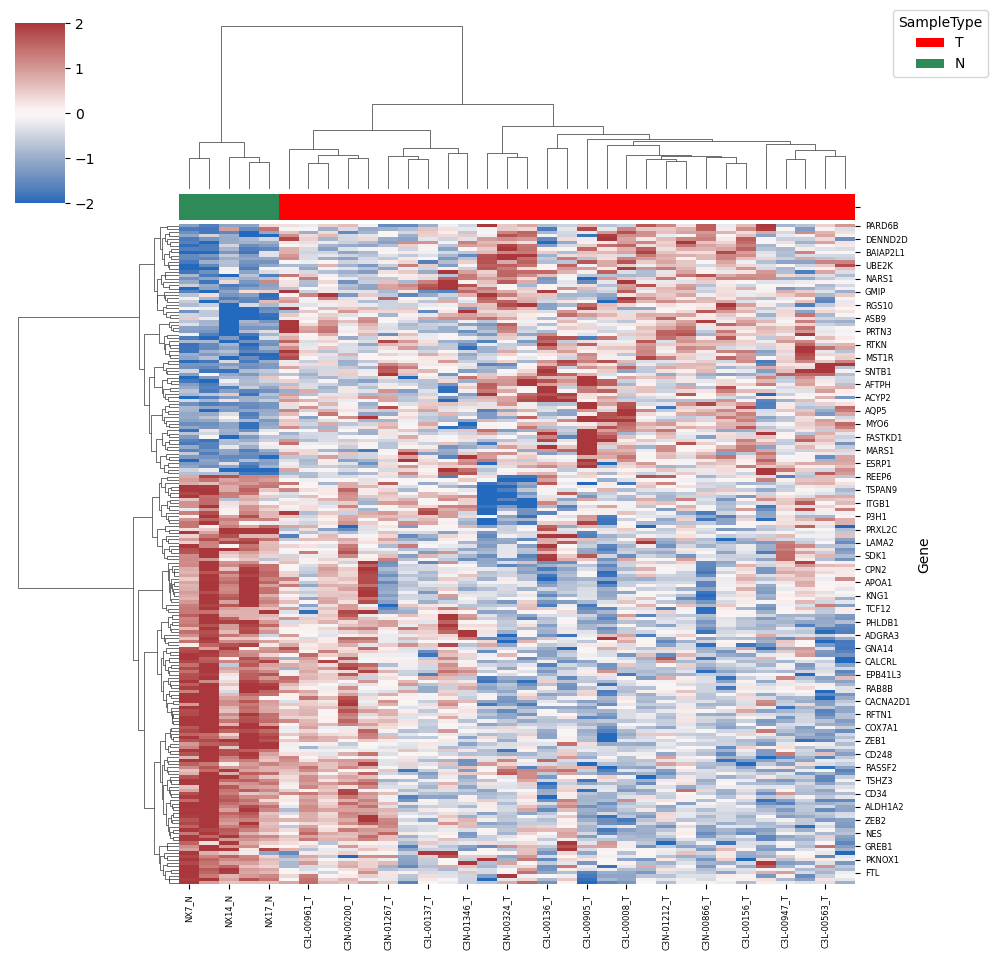

In [14]:

### Heatmap on top 200 important genes on testing set

selected_genes = feature_importance_sort.iloc[0:200, ].index.to_list()
adata_test_selected_genes = adata_test[:, selected_genes]

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(adata_test_selected_genes.X),
    columns=adata_test_selected_genes.var["Gene"],    # genes
    index=adata_test_selected_genes.obs.index   # samples
)
df_scaled_T = df_scaled.T
# Map disease status to colors
disease_status_col = "SampleType"
lut = {"T": "red", "N": "seagreen"}
dict_colors = adata_test_selected_genes.obs[disease_status_col].map(lut).to_dict()
col_colors = pd.Series(dict_colors)[df_scaled_T.columns]

print(f"Total number of samples: {len(col_colors)}")

# Cluster map
fig = plt.figure(figsize =(9,9))
g= sns.clustermap(
    df_scaled_T,
    col_colors=col_colors,
    cmap="vlag",
    method="ward",
    center=0,
    vmin=-2,
    vmax=2,
    xticklabels=True,
    yticklabels=True
)
# Option 2: Skip some labels (subsample)
yticks = g.ax_heatmap.get_yticks()              # tick positions
ylabels = [lab.get_text() for lab in g.ax_heatmap.get_yticklabels()]  # label texts

skip = 4  # show every 5th gene
g.ax_heatmap.set_yticks(yticks[::skip])
g.ax_heatmap.set_yticklabels(ylabels[::skip], fontsize=6, rotation=0)

# Option 2: Skip some labels (subsample)
xticks = g.ax_heatmap.get_xticks()              # tick positions
xlabels = [lab.get_text() for lab in g.ax_heatmap.get_xticklabels()]  # label texts

skip = 2  # show every 5th gene
g.ax_heatmap.set_xticks(xticks[::skip])
g.ax_heatmap.set_xticklabels(xlabels[::skip], fontsize=6, rotation=90)


# Legend
handles = [Patch(facecolor=lut[name]) for name in lut]
plt.legend(
    handles,
    lut,
    title=disease_status_col,
    bbox_to_anchor=(1, 1),
    bbox_transform=plt.gcf().transFigure,
    loc="upper right"
)
plt.show()


In [15]:
print(np.isfinite(df_scaled_T.values).all()) 

True


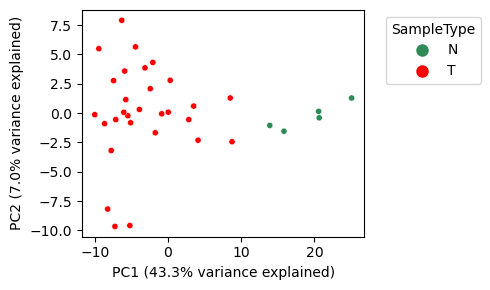

In [16]:

### PCA on top 200 important genes on testing set

scaler = StandardScaler()
df_scaled = scaler.fit_transform(adata_test_selected_genes.X)
pca = PCA()
pca_result = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(
    data = pca_result[:, :2],
    columns= ['PC1', 'PC2'],
    index = adata_test_selected_genes.obs.index
).join(adata_test_selected_genes.obs)

var_explained = pca.explained_variance_ratio_ * 100

disease_status_col = "SampleType"

color_dict = {
    'T': 'red',      # Red
    'N': 'seagreen'   # Green
}
legend_order = ['N', 'T']

fig = plt.figure(figsize =(6,3))
sns.scatterplot(
    data = df_pca,
    x = 'PC1',
    y = 'PC2',
    hue = disease_status_col,
    s = 20,
    palette=color_dict
)

plt.xlabel(f'PC1 ({var_explained[0]:.1f}% variance explained)')
plt.ylabel(f'PC2 ({var_explained[1]:.1f}% variance explained)')

# Create handles and labels in the specific order
handles = []
labels = []
for category in legend_order:
    if category in color_dict:  # Make sure the category exists in your dictionary
        handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict[category], markersize=10))
        labels.append(category)

# Create the legend with the ordered handles and labels
plt.legend(handles, labels, title=disease_status_col, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.85, 1])  
plt.show()



/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_29597/1867634640.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] > 0]["Gene"].to_list()


          Gene_set                                               Term Overlap  \
0  KEGG_2021_Human                        Aminoacyl-tRNA biosynthesis    4/66   
1  KEGG_2021_Human                          Selenocompound metabolism    2/17   
2  KEGG_2021_Human  Phenylalanine, tyrosine and tryptophan biosynt...     1/6   
3  KEGG_2021_Human                                     Tight junction   3/169   
4  KEGG_2021_Human                                         Peroxisome    2/82   

    P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0  0.000116          0.005919            0                     0   17.797491   
1  0.001868          0.047626            0                     0   35.872072   
2  0.022587          0.326820            0                     0   53.117333   
3  0.026586          0.326820            0                     0    4.891401   
4  0.038925          0.326820            0                     0    6.704054   

   Combined Score               

<Axes: title={'center': 'UpRegulated 76 proteins from top 200 features'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

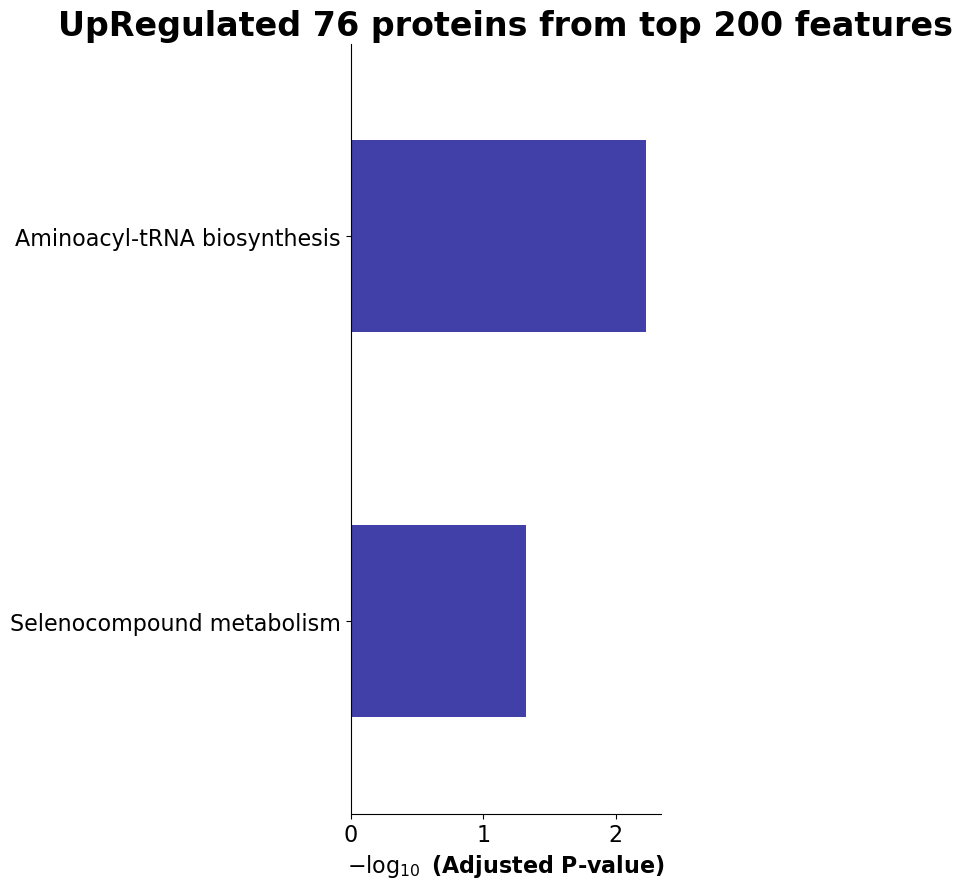

In [24]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] > 0]["Gene"].to_list()
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=glist, # or "./tests/data/gene_list.txt",
                 #gene_sets=['MSigDB_Hallmark_2020'],
                 gene_sets=['KEGG_2021_Human'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )
print(enr.results.head(5))
barplot(enr.results, cutoff=0.1, title=f'UpRegulated {len(glist)} proteins from top 200 features', figsize=(4, 10), color='darkblue')

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_29597/3919987112.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] < 0]["Gene"].to_list()


          Gene_set                                             Term Overlap  \
0  KEGG_2021_Human  Arrhythmogenic right ventricular cardiomyopathy    6/77   
1  KEGG_2021_Human                         ECM-receptor interaction    5/88   
2  KEGG_2021_Human                   Human papillomavirus infection   9/331   
3  KEGG_2021_Human                      Hypertrophic cardiomyopathy    5/90   
4  KEGG_2021_Human                          Proteoglycans in cancer   7/205   

    P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0  0.000008          0.001190            0                     0   14.183576   
1  0.000219          0.007844            0                     0   10.019743   
2  0.000224          0.007844            0                     0    4.752525   
3  0.000244          0.007844            0                     0    9.782996   
4  0.000294          0.007844            0                     0    5.946042   

   Combined Score                           

<Axes: title={'center': 'DownRegulated 124 proteins from top 200 features'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

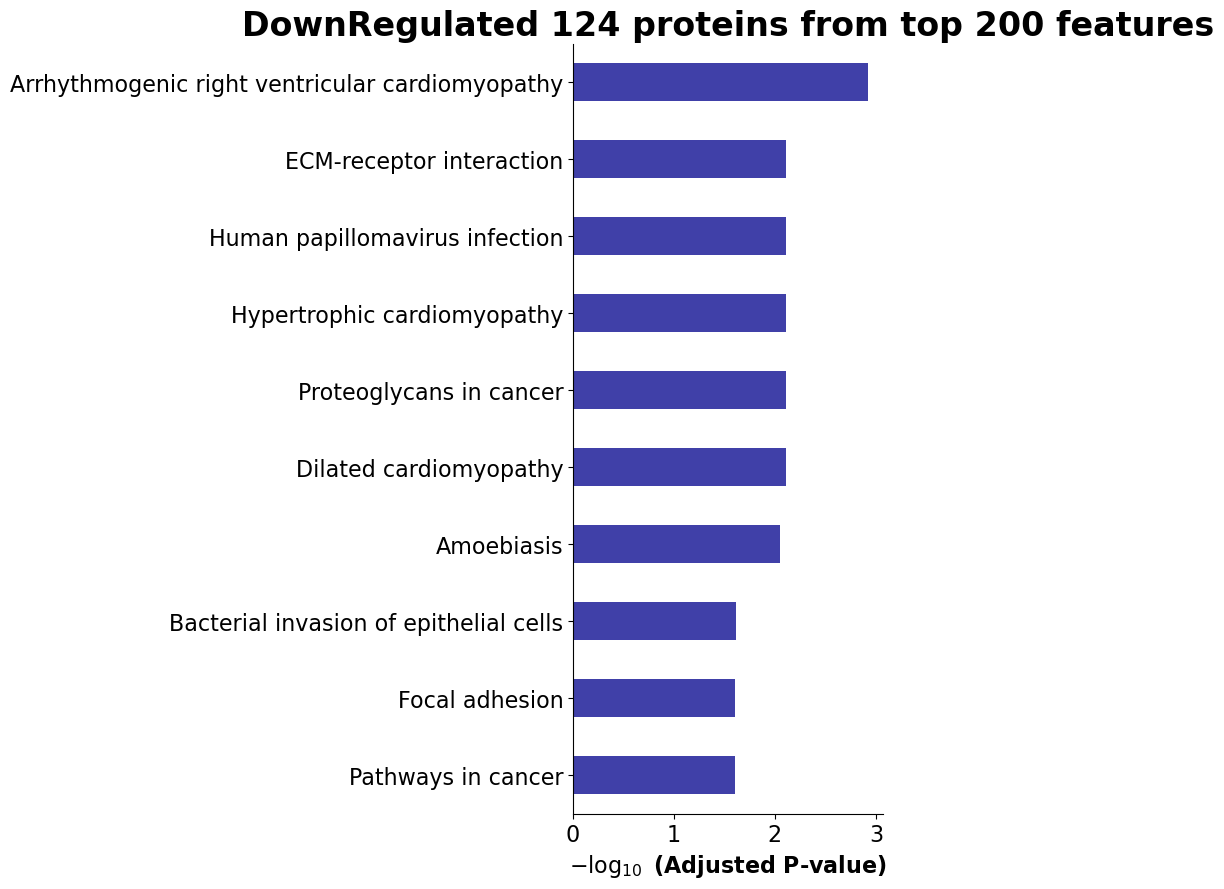

In [25]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] < 0]["Gene"].to_list()
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=glist, # or "./tests/data/gene_list.txt",
                 #gene_sets=['MSigDB_Hallmark_2020'],
                 gene_sets=['KEGG_2021_Human'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )
print(enr.results.head(5))
barplot(enr.results, cutoff=0.1, title=f'DownRegulated {len(glist)} proteins from top 200 features', figsize=(4, 10), color='darkblue')

          Gene_set                                             Term Overlap  \
0  KEGG_2021_Human  Arrhythmogenic right ventricular cardiomyopathy    6/77   
1  KEGG_2021_Human                   Human papillomavirus infection  12/331   
2  KEGG_2021_Human                          Hippo signaling pathway   7/163   
3  KEGG_2021_Human                         ECM-receptor interaction    5/88   
4  KEGG_2021_Human                      Hypertrophic cardiomyopathy    5/90   

    P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0  0.000122          0.011332            0                     0    8.594018   
1  0.000132          0.011332            0                     0    3.898019   
2  0.001290          0.072309            0                     0    4.567158   
3  0.001904          0.072309            0                     0    6.091134   
4  0.002102          0.072309            0                     0    5.947210   

   Combined Score                           

<Axes: title={'center': 'DisRegulated 200 proteins from top 200 features'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

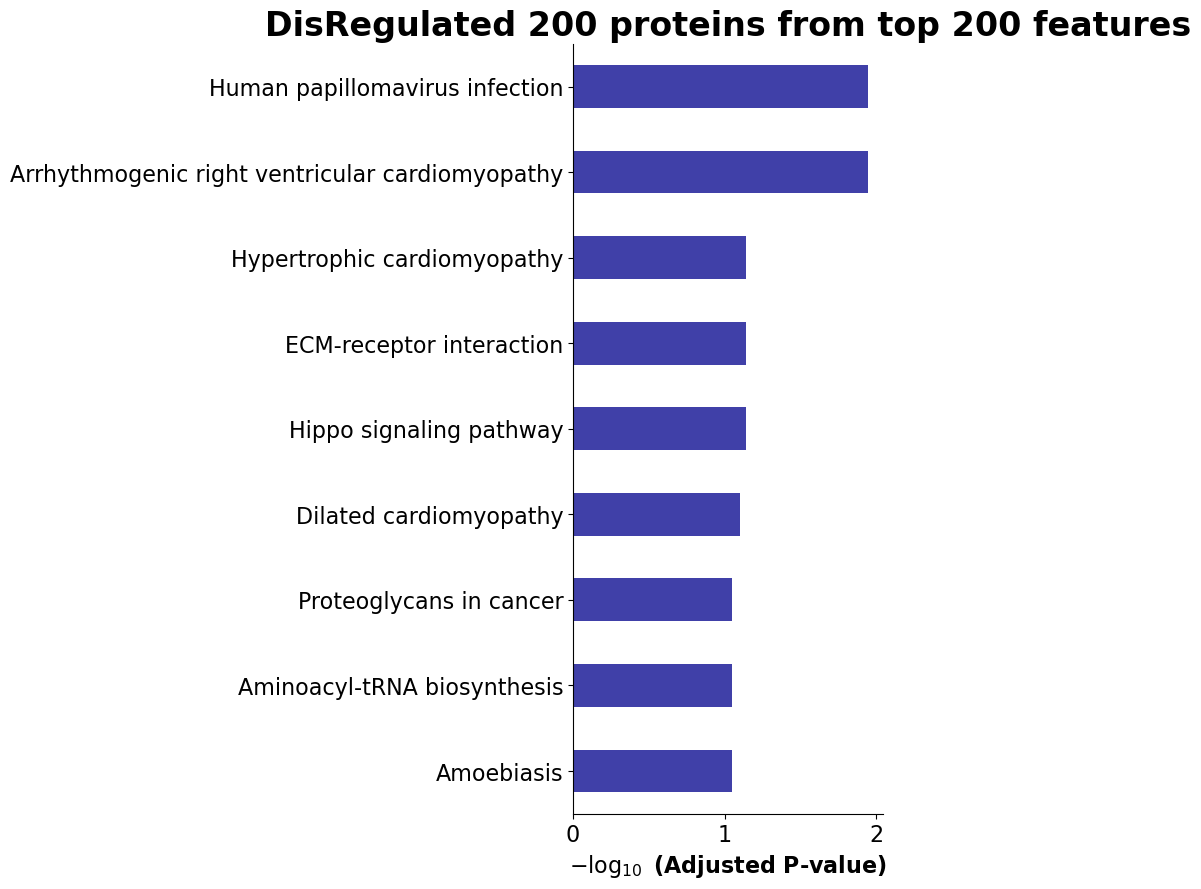

In [27]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
glist = feature_importance_sort.iloc[0:200, ]["Gene"].to_list()
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=glist, # or "./tests/data/gene_list.txt",
                 #gene_sets=['MSigDB_Hallmark_2020'],
                 gene_sets=['KEGG_2021_Human'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None # don't write to disk
                )
print(enr.results.head(5))
barplot(enr.results, cutoff=0.1, title=f'DisRegulated {len(glist)} proteins from top 200 features', figsize=(4, 10), color='darkblue')